In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Analisis exploratorio y preparacion de los datos


## Carga y Limpieza de Datos

In [34]:
# 1. Cargar el dataset usando la ruta relativa
ruta = '../rideshare_kaggle.csv'
df = pd.read_csv(ruta)

### Visualizar datos faltantes

In [35]:
# 2. Validar valores nulos en el dataset original

null_values_dict = {column: count for column, count in valores_nulos.items() if count > 0}
na_values_dict = {column: count for column, count in valores_nulos.items() if count > 0}

print(null_values_dict)
print(na_values_dict)


{'price': 55095}
{'price': 55095}


In [42]:
nulos = df.isna().sum().to_frame("n_nulos")
nulos["pct"] = (nulos["n_nulos"] / len(df) * 100).round(2)
nulos[nulos["n_nulos"] > 0].sort_values("pct", ascending=False)


,n_nulos,pct
price,55095,7.95


<Axes: >

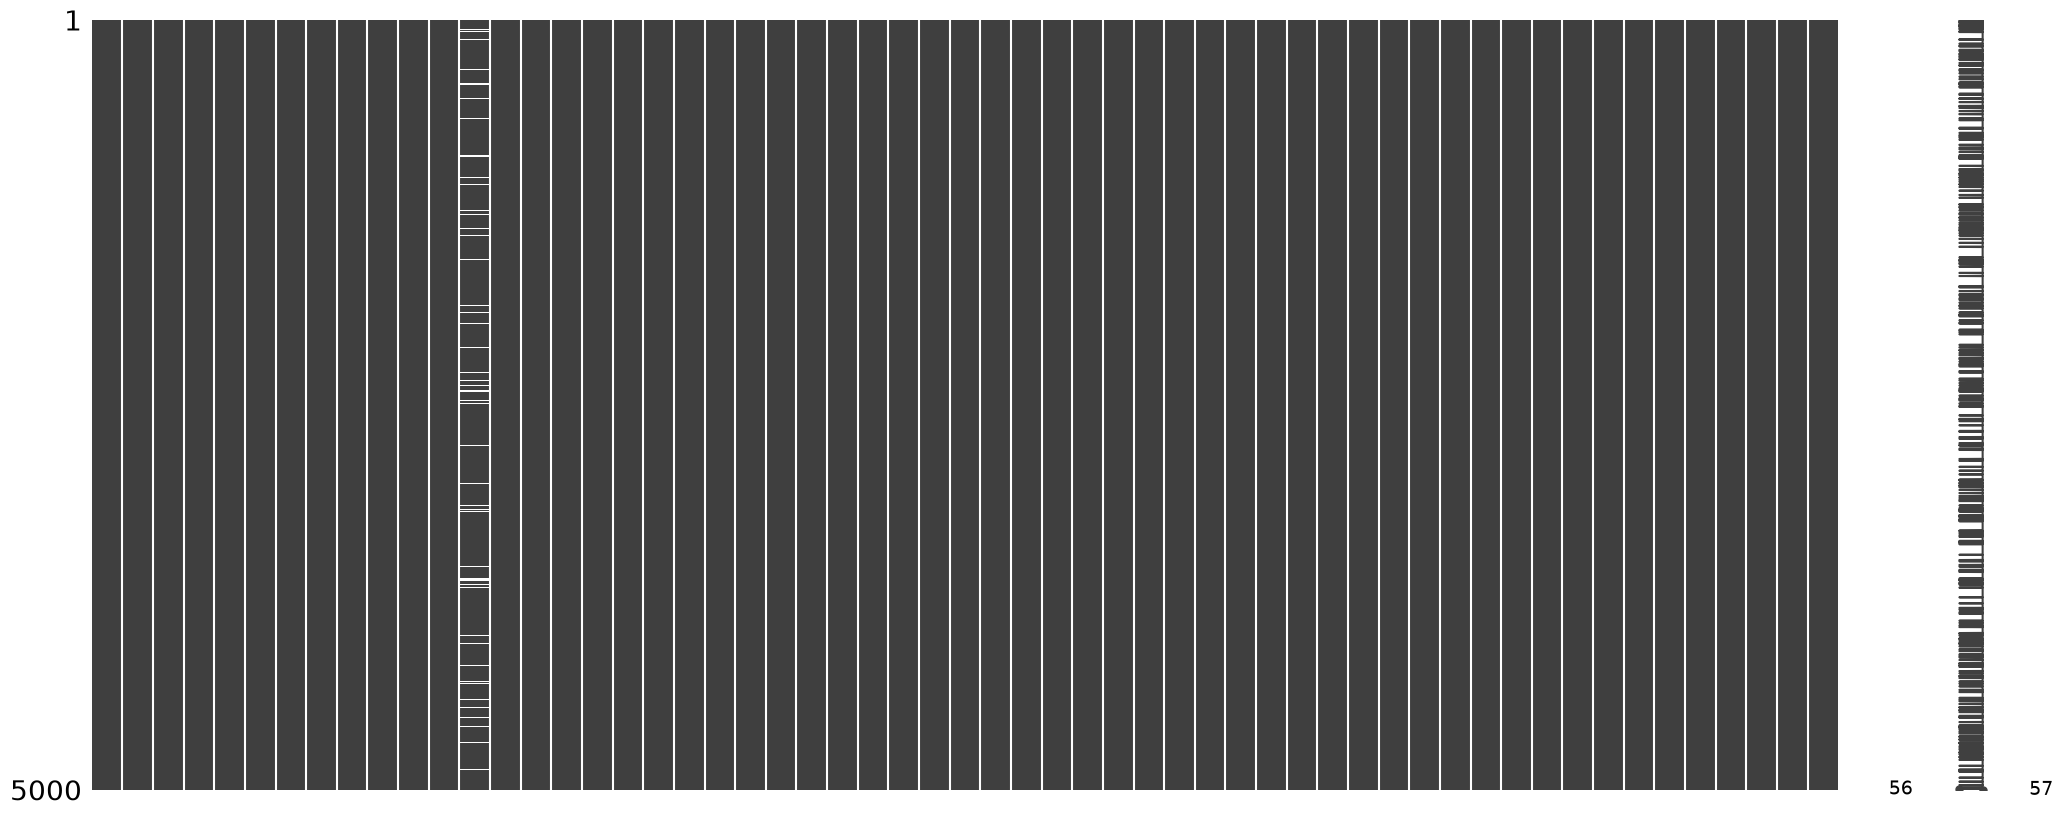

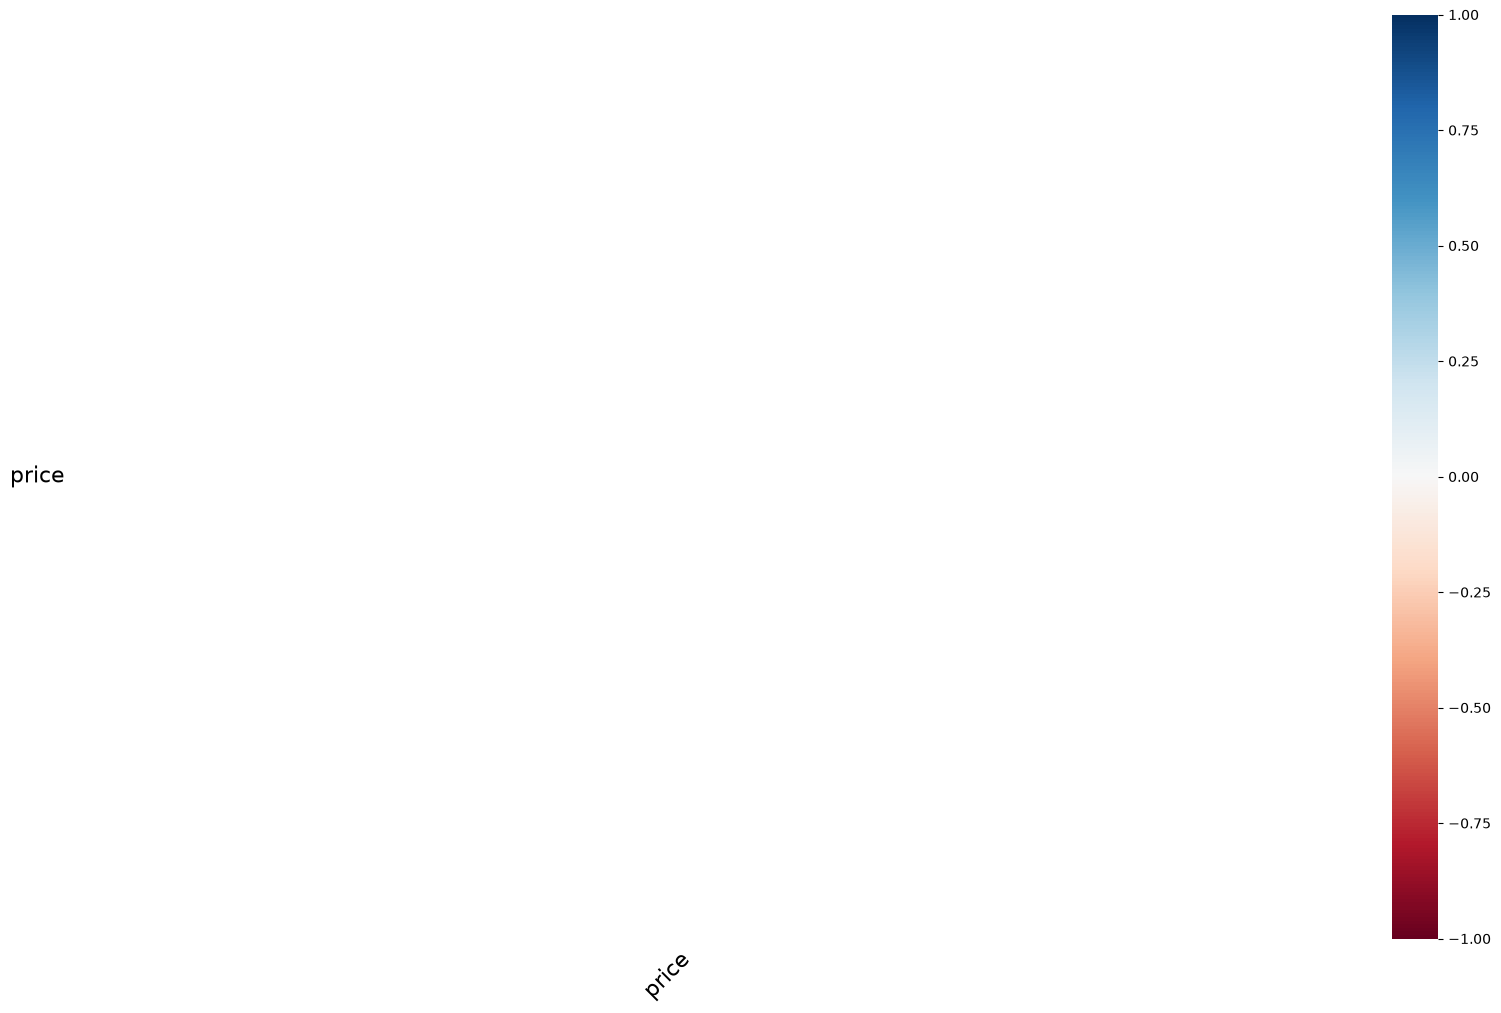

In [43]:
# Visualizar patrones 
msno.matrix(df.sample(5000, random_state=42)) 
msno.heatmap(df)  

In [44]:
# Investigar POR QUÉ faltan: ¿qué tienen en común las filas con price nulo?
df[df["price"].isna()]["name"].value_counts()
df[df["price"].isna()]["cab_type"].value_counts()

cab_type
Uber    55095
Name: count, dtype: int64

In [36]:
# 3. Filtrar los nulos de 'price' (categoría Taxi)
df_clean = df.dropna(subset=['price']).copy()

print(f"Filas originales: {len(df)}")
print(f"Filas limpias (sin Taxi): {len(df_clean)}")
print(f"Dimensiones del dataset: {df_clean.shape}")

Filas originales: 693071
Filas limpias (sin Taxi): 637976
Dimensiones del dataset: (637976, 57)


In [37]:
df_information_original = df_clean.info()

<class 'pandas.DataFrame'>
Index: 637976 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           637976 non-null  str    
 1   timestamp                    637976 non-null  float64
 2   hour                         637976 non-null  int64  
 3   day                          637976 non-null  int64  
 4   month                        637976 non-null  int64  
 5   datetime                     637976 non-null  str    
 6   timezone                     637976 non-null  str    
 7   source                       637976 non-null  str    
 8   destination                  637976 non-null  str    
 9   cab_type                     637976 non-null  str    
 10  product_id                   637976 non-null  str    
 11  name                         637976 non-null  str    
 12  price                        637976 non-null  float64
 13  distance       

### Estadisticas de las variables numericas

In [41]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp,637976.0,1.544046e+09,689202.790112,1.543204e+09,1.543444e+09,1.543737e+09,1.544828e+09,1.545161e+09
hour,637976.0,1.161853e+01,6.948776,0.000000e+00,6.000000e+00,1.200000e+01,1.800000e+01,2.300000e+01
day,637976.0,1.779767e+01,9.982083,1.000000e+00,1.300000e+01,1.700000e+01,2.800000e+01,3.000000e+01
month,637976.0,1.158655e+01,0.492452,1.100000e+01,1.100000e+01,1.200000e+01,1.200000e+01,1.200000e+01
price,637976.0,1.654513e+01,9.324359,2.500000e+00,9.000000e+00,1.350000e+01,2.250000e+01,9.750000e+01
distance,637976.0,2.189261e+00,1.135413,2.000000e-02,1.270000e+00,2.160000e+00,2.930000e+00,7.860000e+00
surge_multiplier,637976.0,1.015068e+00,0.095422,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00
latitude,637976.0,4.233816e+01,0.047856,4.221480e+01,4.235030e+01,4.235190e+01,4.236470e+01,4.236610e+01
longitude,637976.0,-7.106614e+01,0.020303,-7.110540e+01,-7.108100e+01,-7.106310e+01,-7.105420e+01,-7.103300e+01
temperature,637976.0,3.958241e+01,6.725500,1.891000e+01,3.645000e+01,4.049000e+01,4.358000e+01,5.722000e+01


### Calidad de los datos
- cuántas filas duplicadas hay
- Precios imposibles
- Rango de horas

In [45]:
df.duplicated().sum()           
df = df.drop_duplicates()

(df["price"] <= 0).sum()         
df["hour"].between(0, 23).all()  
df.nunique().sort_values()   

timezone                            1
month                               2
cab_type                            2
uvIndex                             3
icon                                7
surge_multiplier                    7
short_summary                       9
latitude                           11
long_summary                       11
longitude                          12
source                             12
destination                        12
product_id                         13
name                               13
day                                17
moonPhase                          18
uvIndexTime                        20
temperatureHighTime                23
temperatureMaxTime                 23
hour                               24
temperatureMinTime                 25
windGustTime                       25
apparentTemperatureHighTime        27
apparentTemperatureMaxTime         27
precipProbability                  29
apparentTemperatureMinTime         29
temperatureL

### Fechas y variables derivadas

In [46]:
df["datetime"] = pd.to_datetime(df["datetime"])   

df["dia_semana"] = df["datetime"].dt.dayofweek    
df["es_fin_semana"] = (df["dia_semana"] >= 5).astype(int)

### Analisis exploratorio

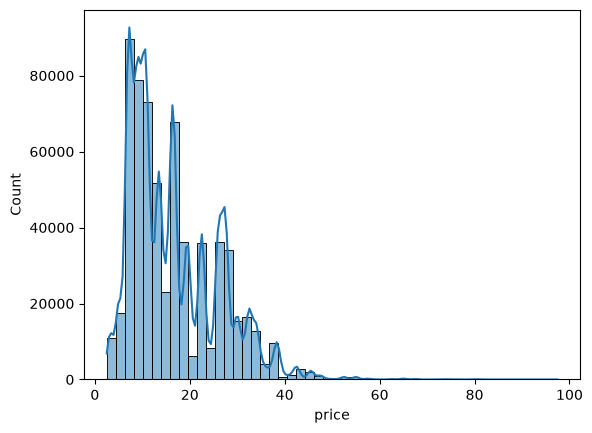

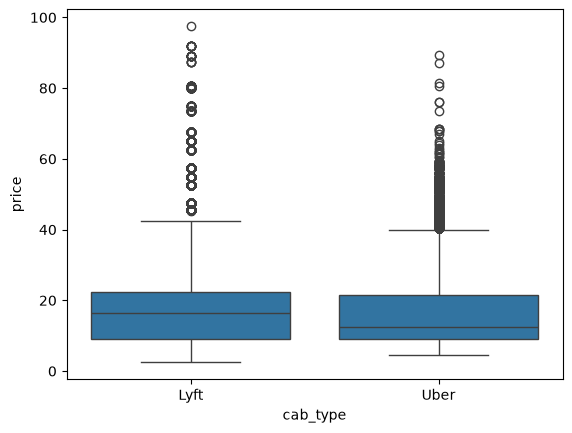

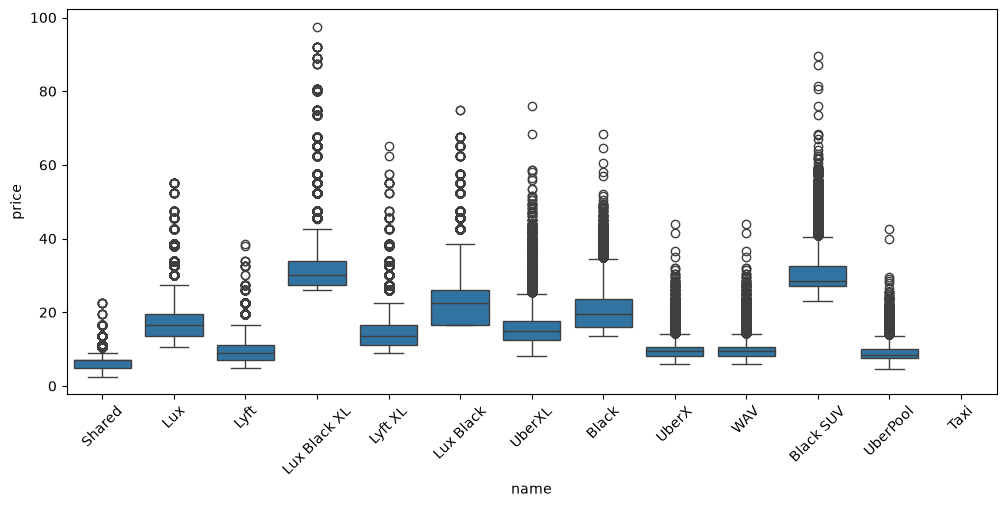

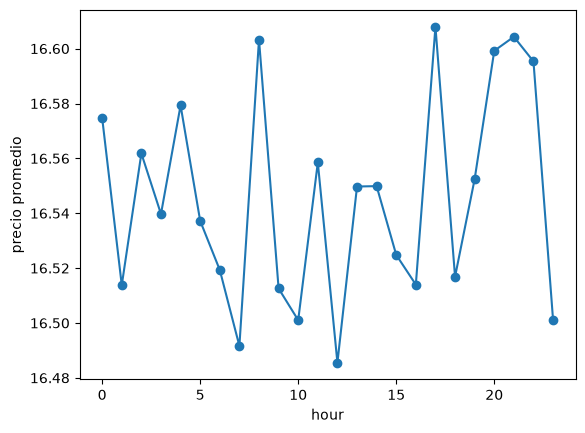

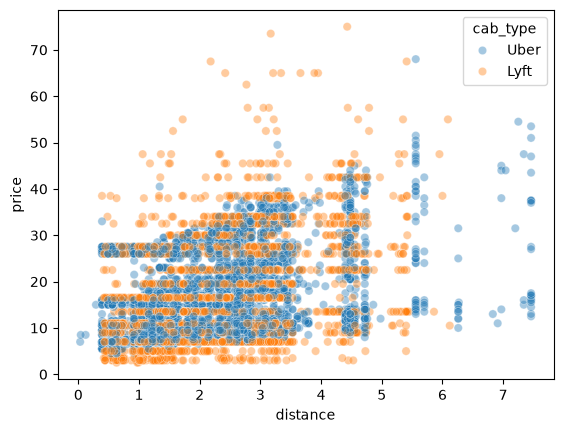

In [47]:
# Distribución del objetivo (price): ¿sesgo? ¿outliers?
sns.histplot(df["price"].dropna(), bins=50, kde=True)
plt.show()

# Precio por empresa y por tipo de servicio
sns.boxplot(data=df, x="cab_type", y="price")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="name", y="price")
plt.xticks(rotation=45)
plt.show()

# Precio promedio por hora del día
df.groupby("hour")["price"].mean().plot(marker="o")
plt.ylabel("precio promedio")
plt.show()

# Distancia vs precio (muestra para no saturar el gráfico)
sns.scatterplot(data=df.sample(10000, random_state=42),
                x="distance", y="price", hue="cab_type", alpha=0.4)
plt.show()

### Correlaciones y redundancias

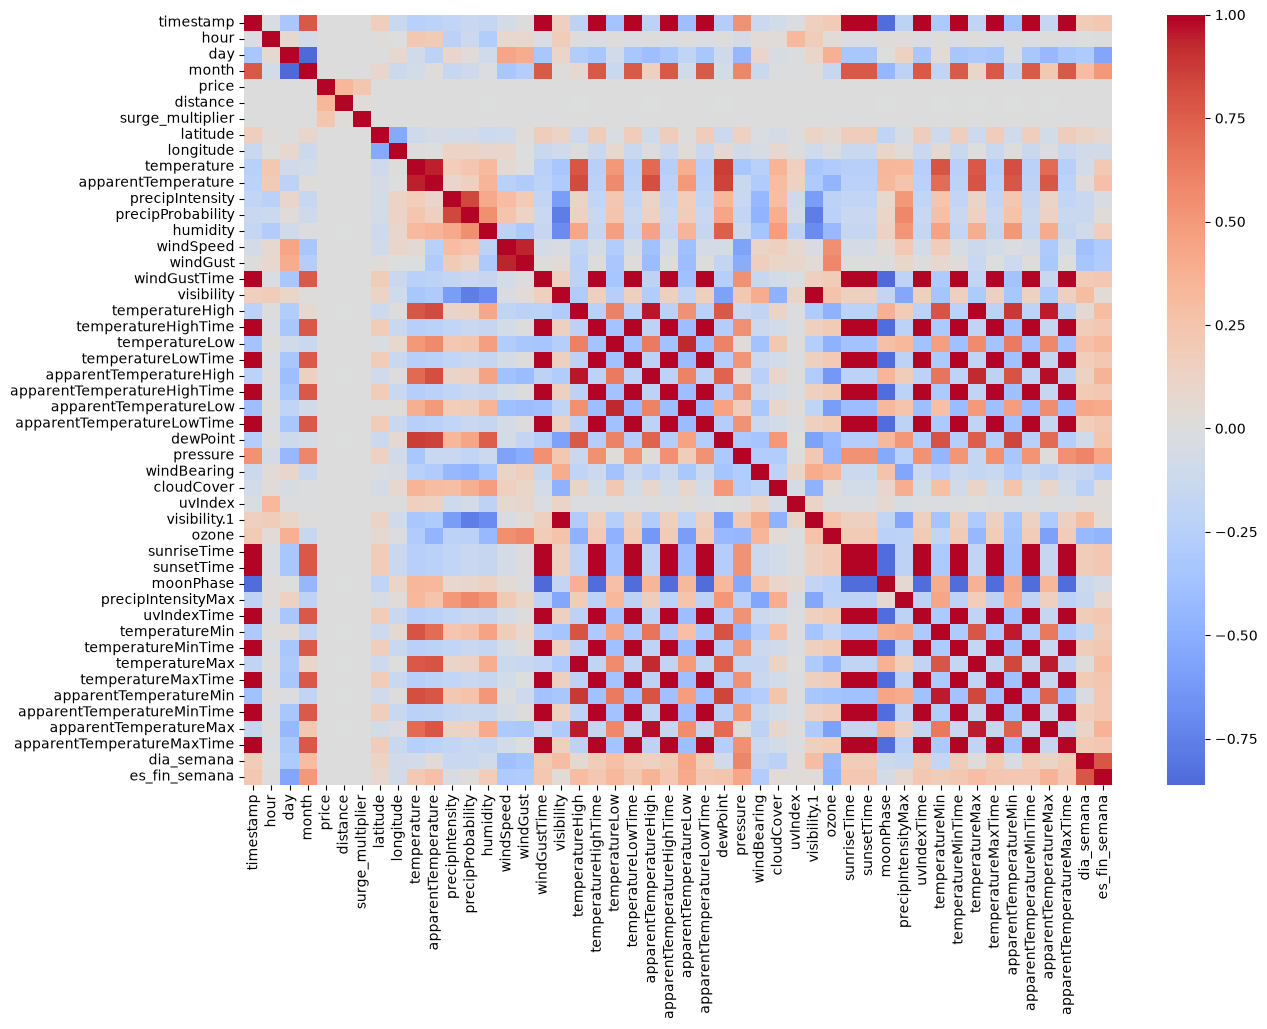

visibility               visibility.1                   1.000000
sunriseTime              sunsetTime                     1.000000
sunsetTime               uvIndexTime                    0.999997
sunriseTime              uvIndexTime                    0.999997
temperatureHighTime      apparentTemperatureHighTime    0.999986
                                                          ...   
temperatureHigh          apparentTemperatureMax         0.951057
temperature              apparentTemperature            0.946166
windSpeed                windGust                       0.937638
temperatureLow           apparentTemperatureLow         0.933953
apparentTemperatureHigh  temperatureMax                 0.926454
Length: 89, dtype: float64

In [48]:
num = df.select_dtypes(include="number")
corr = num.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

# Pares de variables casi idénticas (candidatas a eliminar)
corr_abs = corr.abs()
mask = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)  # solo triángulo superior
pares = corr_abs.where(mask).stack().sort_values(ascending=False)
pares[pares > 0.9]

## Prevención de fuga de información

La fuga de información ocurre cuando el modelo se entrena con datos que no estarían
disponibles en el momento real de la predicción, o cuando el conjunto de prueba
influye en el proceso de entrenamiento. Produce métricas optimistas que no se
sostienen frente a datos nuevos.

En este proyecto la predicción se realiza en el instante en que un usuario solicita
una cotización de viaje. Toda variable que no se conozca en ese instante queda fuera
del modelo.

Aplicamos cuatro controles, desarrollados en las celdas siguientes:

1. Auditoría de variables, para descartar identificadores, columnas redundantes y
   variables cuyo valor solo se conoce después del viaje.
2. Encapsulamiento de todas las transformaciones en un `Pipeline`, ajustado
   exclusivamente con los datos de entrenamiento.
3. Verificación de que ninguna variable predictora reproduzca la variable objetivo.
4. Justificación del método de separación entre entrenamiento y prueba.

In [18]:
import pandas as pd

# ---------------------------------------------------------------
# Control 1: auditoría de variables predictoras
# ---------------------------------------------------------------

# 1.a Identificadores y marcas de tiempo.
# No describen el viaje, solo lo etiquetan. Un identificador puede permitir que el
# modelo memorice observaciones individuales en lugar de aprender el patrón.
cols_identificadores = ['id', 'timestamp', 'datetime', 'product_id']

# 1.b Variables conocidas solo después del evento.
# El dataset incluye agregados meteorológicos del DÍA COMPLETO (máximos, mínimos,
# valores altos y bajos) y marcas de tiempo futuras (hora del amanecer, del atardecer,
# del pico de índice UV). En el momento de cotizar un viaje a las 10:00 a.m. todavía
# no se conoce la temperatura máxima de ese día. Usarlas sería fuga de información
# según el punto 6.6: "no se utilicen variables que solo se conocen después del
# evento que se desea predecir".
patrones_futuro = ('Max', 'Min', 'High', 'Low')
cols_futuro = [
    c for c in df_clean.columns
    if c.endswith('Time') or any(p in c for p in patrones_futuro)
]

# 1.c Columnas duplicadas o redundantes.
# 'visibility.1' es una copia de 'visibility'. 'product_id' codifica exactamente la
# misma información que 'name', por eso ya está en la lista de identificadores.
cols_redundantes = [c for c in df_clean.columns if c.endswith('.1')]

# 1.d Resúmenes de texto del día completo.
# 'long_summary' describe el pronóstico de TODO el día (por ejemplo "Rain throughout
# the day"), por lo que tiene el mismo problema que los máximos y mínimos diarios.
# 'short_summary' e 'icon' describen la condición de la hora actual y sí se conocen al
# cotizar; no se excluyen por fuga, aunque el modelo no las usa (ver el Pipeline).
cols_resumen_diario = ['long_summary']

cols_excluidas = sorted(set(cols_identificadores + cols_futuro + cols_redundantes
                            + cols_resumen_diario)
                        & set(df_clean.columns))

print(f"Variables excluidas por auditoría: {len(cols_excluidas)}")
for c in cols_excluidas:
    print(f"  - {c}")

df_auditado = df_clean.drop(columns=cols_excluidas)
print(f"\nVariables conservadas: {df_auditado.shape[1] - 1} predictoras + 1 objetivo")

Variables excluidas por auditoría: 27
  - apparentTemperatureHigh
  - apparentTemperatureHighTime
  - apparentTemperatureLow
  - apparentTemperatureLowTime
  - apparentTemperatureMax
  - apparentTemperatureMaxTime
  - apparentTemperatureMin
  - apparentTemperatureMinTime
  - datetime
  - id
  - long_summary
  - precipIntensityMax
  - product_id
  - sunriseTime
  - sunsetTime
  - temperatureHigh
  - temperatureHighTime
  - temperatureLow
  - temperatureLowTime
  - temperatureMax
  - temperatureMaxTime
  - temperatureMin
  - temperatureMinTime
  - timestamp
  - uvIndexTime
  - visibility.1
  - windGustTime

Variables conservadas: 29 predictoras + 1 objetivo


In [19]:
# ---------------------------------------------------------------
# Control 3: ninguna variable predictora reproduce la variable objetivo
# ---------------------------------------------------------------

num = df_auditado.select_dtypes(include='number')
corr_precio = num.corr()['price'].drop('price').abs().sort_values(ascending=False)

print("Correlación absoluta con 'price' (5 más altas):")
print(corr_precio.head(5).round(4))

sospechosas = corr_precio[corr_precio > 0.95]
if len(sospechosas) == 0:
    print("\nNinguna variable numérica supera |r| = 0.95. No se detecta duplicación del objetivo.")
else:
    print(f"\nRevisar: {list(sospechosas.index)}")

Correlación absoluta con 'price' (5 más altas):
distance            0.3451
surge_multiplier    0.2405
latitude            0.0021
moonPhase           0.0016
visibility          0.0015
Name: price, dtype: float64

Ninguna variable numérica supera |r| = 0.95. No se detecta duplicación del objetivo.


**Resultado del control 3.** Ninguna variable numérica supera |r| = 0.95 con `price`.
Las más relacionadas son `distance` (0.35) y `surge_multiplier` (0.24), ambas conocidas
en el momento de cotizar; el resto está por debajo de 0.01. No hay entre las predictoras
una copia disfrazada del precio.

Este control es diagnóstico: se calcula antes de la división, pero no se usó para
eliminar ni seleccionar variables, por lo que el conjunto de prueba no influye en el
modelo.

### Separación de entrenamiento y prueba

Se utilizó `train_test_split` con 80% para entrenamiento y 20% para prueba,
`random_state=42`, sobre 582.066 observaciones (637.976 registros con precio,
menos 55.910 filas exactamente duplicadas).

El conjunto de datos fue declarado como de corte transversal: cada fila corresponde
a una cotización independiente, no a una secuencia donde el valor de una observación
dependa de la anterior. Por esta razón la separación aleatoria es apropiada y no se
requiere un corte temporal.

Revisamos la existencia de grupos naturales. El dataset contiene un número acotado de
rutas (combinaciones origen-destino) y de tipos de servicio, que se repiten a lo largo
del período. Esto implica que observaciones similares pueden quedar repartidas entre
ambos conjuntos. Lo consideramos aceptable porque el objetivo del modelo es cotizar
viajes sobre esas mismas rutas y servicios, no generalizar a rutas nunca vistas. La
alternativa, agrupar por ruta, respondería a una pregunta distinta a la planteada.

Como control adicional se eliminaron las filas exactamente duplicadas antes de dividir,
para que una misma observación no aparezca simultáneamente en entrenamiento y prueba.

La sección *Robustez de la separación*, más adelante, comprueba empíricamente que ni
la repetición de rutas ni el orden temporal inflan las métricas.

In [20]:
duplicadas = df_auditado.duplicated().sum()
print(f"Filas exactamente duplicadas: {duplicadas} ({duplicadas/len(df_auditado)*100:.2f}%)")

df_final = df_auditado.drop_duplicates().reset_index(drop=True)
print(f"Filas tras eliminar duplicados: {len(df_final)}")

Filas exactamente duplicadas: 55910 (8.76%)
Filas tras eliminar duplicados: 582066


# División de Datos

In [5]:
from sklearn.model_selection import train_test_split

# Separar características (X) y variable objetivo (y)
X = df_clean.drop(columns=['price'])
y = df_clean['price']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Seleccionar columnas numéricas para las pruebas iniciales
numeric_cols = X_train.select_dtypes(include=['number']).columns
X_train_num = X_train[numeric_cols].fillna(0)
X_test_num = X_test[numeric_cols].fillna(0)

print(f"Conjunto de Entrenamiento (X_train): {X_train_num.shape}")
print(f"Conjunto de Prueba (X_test):         {X_test_num.shape}")

Conjunto de Entrenamiento (X_train): (510380, 45)
Conjunto de Prueba (X_test):         (127596, 45)


# Modelo 1 - Baseline (Regresión Lineal)

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Entrenar el modelo lineal simple
baseline_model = LinearRegression()
baseline_model.fit(X_train_num, y_train)

# Predicción y métricas
y_pred_base = baseline_model.predict(X_test_num)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base = mean_absolute_error(y_test, y_pred_base)
r2_base = r2_score(y_test, y_pred_base)

print("--- MÉTRICAS MODELO BASELINE (Linear Regression) ---")
print(f"RMSE: ${rmse_base:.2f}")
print(f"MAE:  ${mae_base:.2f}")
print(f"R²:   {r2_base:.4f}")

--- MÉTRICAS MODELO BASELINE (Linear Regression) ---
RMSE: $8.48
MAE:  $6.95
R²:   0.1749


# Modelo 2 - Candidato Avanzado (Random Forest con limite de profundidad)

Nota de experimentación: Se entrenó un RandomForestRegressor con las variables numéricas. Debido a la alta carga computacional (7.5 min) y a un $R^2$ de 0.1506, se optó por utilizar HistGradientBoostingRegressor como modelo candidato principal por su eficiencia y compatibilidad con datos masivos.

In [7]:
from sklearn.ensemble import RandomForestRegressor

# Limitamos max_depth=15 para evitar que consuma toda la RAM de la Mac y sea ultrarrápido
rf = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)

print("Entrenando Random Forest...")
rf.fit(X_train_num, y_train)

y_pred_rf = rf.predict(X_test_num)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- MÉTRICAS MODELO CANDIDATO (Random Forest) ---")
print(f"RMSE: ${rmse_rf:.2f}")
print(f"MAE:  ${mae_rf:.2f}")
print(f"R²:   {r2_rf:.4f}")

Entrenando Random Forest...



--- MÉTRICAS MODELO CANDIDATO (Random Forest) ---
RMSE: $8.61
MAE:  $7.04
R²:   0.1506


In [8]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelo optimizado para grandes volúmenes de datos (muy rápido en Mac)
hgb_model = HistGradientBoostingRegressor(random_state=42, max_iter=100)

print("Entrenando HistGradientBoostingRegressor...")
hgb_model.fit(X_train_num, y_train)

# Predicciones
y_pred_hgb = hgb_model.predict(X_test_num)

# Métricas
rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb))
mae_hgb = mean_absolute_error(y_test, y_pred_hgb)
r2_hgb = r2_score(y_test, y_pred_hgb)

print("\n--- MÉTRICAS MODELO CANDIDATO (HistGradientBoosting) ---")
print(f"RMSE: ${rmse_hgb:.2f}")
print(f"MAE:  ${mae_hgb:.2f}")
print(f"R²:   {r2_hgb:.4f}")

Entrenando HistGradientBoostingRegressor...



--- MÉTRICAS MODELO CANDIDATO (HistGradientBoosting) ---
RMSE: $8.45
MAE:  $6.94
R²:   0.1817


# One-Hot Encoding

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------------
# Control 2: todas las transformaciones dentro de un Pipeline
# ---------------------------------------------------------------

X = df_final.drop(columns=['price'])
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cols_num = X_train.select_dtypes(include='number').columns.tolist()
cols_cat = ['name', 'cab_type']

preprocesador = ColumnTransformer(
    transformers=[
        # La mediana se calcula solo con X_train. Se usa mediana y no cero porque
        # un cero en temperatura, presión o latitud es un valor físicamente posible
        # pero falso, que distorsionaría el aprendizaje.
        ('num', SimpleImputer(strategy='median'), cols_num),

        # handle_unknown='ignore': si en producción aparece un tipo de servicio que
        # no estaba en entrenamiento, el pipeline lo codifica en ceros en vez de
        # fallar. Esto era lo que el align() resolvía a mano y de forma frágil.
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_cat),
    ],
    # cualquier columna no listada queda fuera de forma explícita. Además de las ya
    # excluidas por fuga, quedan fuera 'source', 'destination', 'short_summary', 'icon'
    # y 'timezone': se conocen al cotizar, pero no se usan por decisión de modelado.
    remainder='drop',
)

print(f"Entrenamiento: {X_train.shape}  |  Prueba: {X_test.shape}")
print(f"Numéricas usadas: {len(cols_num)}  |  Categóricas usadas: {cols_cat}")

Entrenamiento: (465652, 29)  |  Prueba: (116414, 29)
Numéricas usadas: 22  |  Categóricas usadas: ['name', 'cab_type']


### Selección del modelo sin usar el conjunto de prueba

Si se comparan varios modelos con las métricas del conjunto de prueba y se elige el
mejor, el conjunto de prueba ya participó en una decisión del entrenamiento: sus
métricas dejan de ser una estimación honesta del desempeño con datos nuevos.

Por eso la comparación entre candidatos se hace con **validación cruzada de 5 pliegues
sobre `X_train` únicamente**. El conjunto de prueba se usa una sola vez, al final, para
evaluar el modelo ya elegido.

In [10]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.base import clone

# ---------------------------------------------------------------
# Control 2b: la elección del modelo no usa el conjunto de prueba
# ---------------------------------------------------------------

# Todos los candidatos comparten el mismo preprocesamiento, dentro del Pipeline, para
# que en cada pliegue el imputador y el codificador se ajusten solo con ese pliegue.
# El Random Forest no se incluye por su costo computacional (ver nota de experimentación).
candidatos = {
    'Dummy (mediana)':      DummyRegressor(strategy='median'),
    'Regresión lineal':     LinearRegression(),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=42),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
metricas_cv = ('neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2')

resultados_cv = []
for nombre, regresor in candidatos.items():
    pipe_cv = Pipeline(steps=[
        ('preprocesamiento', clone(preprocesador)),
        ('regresor', regresor),
    ])
    # Nota: en cross_validate el prefijo 'test_' se refiere al pliegue de validación
    # dentro de X_train, no al conjunto de prueba.
    r = cross_validate(pipe_cv, X_train, y_train, cv=cv, scoring=metricas_cv)
    resultados_cv.append({
        'modelo': nombre,
        'RMSE':   -r['test_neg_root_mean_squared_error'].mean(),
        'MAE':    -r['test_neg_mean_absolute_error'].mean(),
        'R²':     r['test_r2'].mean(),
        'R² (desv.)': r['test_r2'].std(),
    })

tabla_cv = pd.DataFrame(resultados_cv).set_index('modelo').round(4)
print("--- VALIDACIÓN CRUZADA (5 pliegues, solo X_train) ---")
print(tabla_cv)
print(f"\nModelo elegido: {tabla_cv['R²'].idxmax()}")

--- VALIDACIÓN CRUZADA (5 pliegues, solo X_train) ---
                        RMSE     MAE      R²  R² (desv.)
modelo                                                  
Dummy (mediana)       9.8399  7.4901 -0.0857      0.0010
Regresión lineal      2.5790  1.8214  0.9254      0.0004
HistGradientBoosting  1.8239  1.2176  0.9627      0.0002

Modelo elegido: HistGradientBoosting


**Resultado de la selección.** Con validación cruzada sobre entrenamiento,
HistGradientBoosting obtiene R² = 0.9627 y MAE = $1.22, frente a 0.9254 y $1.82 de la
regresión lineal y a un R² negativo del modelo Dummy. La variación entre pliegues es
mínima (desviación de 0.0002), así que la diferencia entre modelos es estable. La
elección se tomó sin mirar el conjunto de prueba; al evaluarlo una única vez, el
resultado (R² = 0.9628) coincide con la estimación de validación cruzada, lo que indica
que la métrica final no está inflada.

In [11]:
import numpy as np
modelo = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('regresor', HistGradientBoostingRegressor(random_state=42)),
])

# fit() ajusta imputador y codificador ÚNICAMENTE con X_train.
# X_test nunca interviene en el aprendizaje de las transformaciones.
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("--- MÉTRICAS: Pipeline sin fuga de información ---")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

--- MÉTRICAS: Pipeline sin fuga de información ---
RMSE: $1.81
MAE:  $1.22
R²:   0.9628


### Robustez de la separación

Para comprobar que la separación aleatoria no infla las métricas, se reentrena el mismo
Pipeline con dos separaciones más exigentes. Estas pruebas son solo diagnósticas: no se
usan para elegir ni ajustar el modelo.

- **Por grupos naturales (rutas):** las rutas origen-destino del conjunto de prueba
  nunca aparecen en entrenamiento.
- **Temporal:** se entrena con el 80% más antiguo (ordenado por mes, día y hora) y se
  evalúa con el 20% más reciente.

In [12]:
from sklearn.model_selection import GroupShuffleSplit

# ---------------------------------------------------------------
# Control 4: ¿la separación aleatoria genera fuga entre grupos o en el tiempo?
# ---------------------------------------------------------------

def evaluar_separacion(idx_train, idx_test):
    m = clone(modelo).fit(X.iloc[idx_train], y.iloc[idx_train])
    p = m.predict(X.iloc[idx_test])
    return r2_score(y.iloc[idx_test], p), mean_absolute_error(y.iloc[idx_test], p)

# a) Por grupos naturales: rutas origen-destino
rutas = X['source'] + ' -> ' + X['destination']
idx_tr, idx_te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
                      .split(X, y, groups=rutas))
r2_ruta, mae_ruta = evaluar_separacion(idx_tr, idx_te)

# b) Temporal: pasado para entrenar, futuro para evaluar
orden = np.argsort((X['month'] * 10000 + X['day'] * 100 + X['hour']).to_numpy(), kind='stable')
corte = int(len(orden) * 0.8)
r2_temp, mae_temp = evaluar_separacion(orden[:corte], orden[corte:])

print(f"Rutas distintas en el dataset: {rutas.nunique()}")
print(f"{'Separación':<34}{'R²':>8}{'MAE':>9}")
print(f"{'Aleatoria 80/20 (la utilizada)':<34}{r2_score(y_test, y_pred):>8.4f}{mean_absolute_error(y_test, y_pred):>8.2f}$")
print(f"{'Por rutas (rutas no vistas)':<34}{r2_ruta:>8.4f}{mae_ruta:>8.2f}$")
print(f"{'Temporal (pasado -> futuro)':<34}{r2_temp:>8.4f}{mae_temp:>8.2f}$")

Rutas distintas en el dataset: 72
Separación                              R²      MAE
Aleatoria 80/20 (la utilizada)      0.9628    1.22$
Por rutas (rutas no vistas)         0.9523    1.36$
Temporal (pasado -> futuro)         0.9625    1.22$


**Resultado de la robustez.** Con una separación temporal el desempeño es prácticamente
igual (R² = 0.9625), por lo que no hay fuga temporal. Con rutas nunca vistas baja
ligeramente (R² = 0.9523, MAE = $1.36): el modelo aprovecha en parte haber visto cada
ruta, pero la diferencia es pequeña. Esto respalda la decisión de usar una separación
aleatoria, dado que el modelo cotiza viajes sobre las mismas 72 rutas del dataset.

# Exportar el Modelo Final

In [13]:
import joblib, os, sklearn

os.makedirs('modelo', exist_ok=True)

artefacto = {
    'pipeline': modelo,                       # incluye preprocesamiento + regresor
    'columnas_entrada': X_train.columns.tolist(),
    'columnas_excluidas_por_fuga': cols_excluidas,
    'version_sklearn': sklearn.__version__,
    'metricas_test': {
        'rmse': float(np.sqrt(mean_squared_error(y_test, y_pred))),
        'mae': float(mean_absolute_error(y_test, y_pred)),
        'r2': float(r2_score(y_test, y_pred)),
    },
}

joblib.dump(artefacto, 'modelo.joblib')
print("Artefacto guardado en fase-1/modelo.joblib")

Artefacto guardado en fase-1/modelo.joblib


In [14]:
cargado = joblib.load('modelo.joblib')
pipe = cargado['pipeline']

# Se pasan datos CRUDOS, sin preprocesar. El pipeline se encarga de todo.
muestra = X_test.head(500)
pred = pipe.predict(muestra)

print(f"Predicciones generadas: {len(pred)}")
print(f"MAE sobre la muestra: ${mean_absolute_error(y_test.head(500), pred):.2f}")
print(f"\nPrimeras 5 comparaciones:")
for real, p in zip(y_test.head(5), pred[:5]):
    print(f"  real ${real:6.2f}   predicho ${p:6.2f}")

Predicciones generadas: 500
MAE sobre la muestra: $1.27

Primeras 5 comparaciones:
  real $ 22.50   predicho $ 19.56
  real $ 16.50   predicho $ 17.99
  real $ 27.50   predicho $ 26.58
  real $ 52.50   predicho $ 55.65
  real $ 16.00   predicho $ 19.07


In [15]:
import joblib

# 1. Cargar el objeto guardado
artefactos_cargados = joblib.load('modelo.joblib')

# 2. Extraer el modelo y las columnas esperadas
modelo_recuperado = artefactos_cargados['pipeline']
columnas_recuperadas = artefactos_cargados['columnas_entrada']

print("¡Modelo cargado exitosamente en memoria!")
print(f"Tipo de modelo: {type(modelo_recuperado)}")
print(f"Cantidad de variables de entrada esperadas: {len(columnas_recuperadas)}")

¡Modelo cargado exitosamente en memoria!
Tipo de modelo: <class 'sklearn.pipeline.Pipeline'>
Cantidad de variables de entrada esperadas: 29


In [16]:
# Tomamos la primera fila de prueba como ejemplo de entrada
ejemplo = X_test.iloc[[0]]

# Realizamos la predicción con el modelo recargado desde el archivo .joblib
precio_predicho = modelo_recuperado.predict(ejemplo)[0]
precio_real = y_test.iloc[0]

print(f"Precio Real del viaje:     ${precio_real:.2f} USD")
print(f"Precio Predicho (Joblib):  ${precio_predicho:.2f} USD")

Precio Real del viaje:     $22.50 USD
Precio Predicho (Joblib):  $19.56 USD
